In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_excel(r"E:\Data Science by SRK\Machine_learning\project\Taxi_price_prediction_xgboost\cleaned_Taxi_Price_data.xlsx")

In [99]:
df

,Trip_Distance_km,Per_Km_Rate,Trip_Price
0,3.013081,0.800000,36.2624
1,3.634159,1.210000,52.9032
2,3.444576,0.510000,36.4698
3,3.339003,0.630000,15.6180
4,2.265921,1.710000,60.2028
...,...,...,...
946,1.870263,0.620000,34.4049
947,3.849083,0.610000,62.1295
948,2.163323,1.780000,33.1236
949,3.882800,0.820000,61.2090


In [100]:
X = df.drop(columns = ['Trip_Price'])
y = df['Trip_Price']

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

# Modelling

In [102]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print('coefficients : ', model.coef_)
print('Intercept : ', model.intercept_)
print("=====================================")

# Prediction R2
ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)

print("Train_R2 : ", r2_score(y_train, ypred_train))
print("CV_Score_R2", cross_val_score(model, X_train, y_train, cv = 5, scoring = 'r2').mean())
print("Test_R2 : ", r2_score(y_test, ypred_test))

coefficients :  [31.73830668 29.84316326]
Intercept :  -78.30588607799695
Train_R2 :  0.4577205592873693
CV_Score_R2 0.4631779885557982
Test_R2 :  0.4314018733736711


In [103]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.8, random_state = 5)

import statsmodels.formula.api as smf
model1 = smf.ols('y_train~X_train', data = df_train).fit()   # output var upon input var
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     319.5
Date:                Mon, 10 Feb 2025   Prob (F-statistic):          2.53e-101
Time:                        00:17:32   Log-Likelihood:                -3639.1
No. Observations:                 760   AIC:                             7284.
Df Residuals:                     757   BIC:                             7298.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -78.3059      5.515    -14.198      0.000     -89.133     -67.479
X_train[0]    31.7383      1.389     22.858      0.000      29.013      34.464
X_train[1]    29.8432      2.527     11.808      0.000      24.882      34.805
==============================================================================
Omnibus:                      687.379   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20630.550
Skew:                           4.091   Prob(JB):                         0.00
Kurtosis:                      27.177   Cond. No.                         19.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

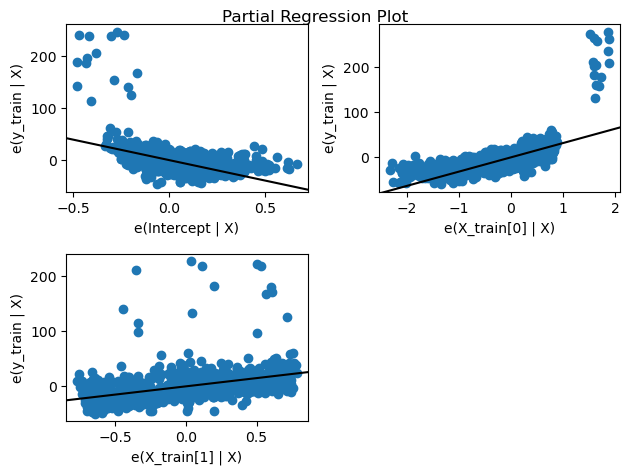

In [104]:
import statsmodels.api as sm

sm.graphics.plot_partregress_grid(model1)
plt.show()

**check for influential records**

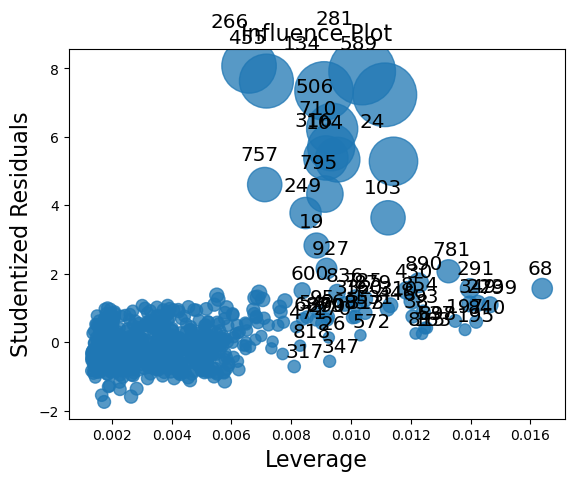

In [105]:
import statsmodels.api as sm

sm.graphics.influence_plot(model1)
plt.show()

In [106]:
# drop the influential records

X = df.drop(index = [506,266,927,317,347,68,572,347,291,781,103,19,757,795,249,710,104], inplace = True)

X = df.drop(columns = ['Trip_Price'])
y = df['Trip_Price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 4)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("intercept : ", model.intercept_)
print("coefficient : ", model.coef_)

ypred_train = model.predict(X_train)
print("Train R2 : ", r2_score(y_train, ypred_train))
print("cross_val_score : ", cross_val_score(model, X_train, y_train, cv = 5).mean())

ypred_test = model.predict(X_test)
print("Test R2 : ", r2_score(y_test, ypred_test))

intercept :  -65.65270508163889
coefficient :  [28.87412257 25.90871711]
Train R2 :  0.4424375187826618
cross_val_score :  0.4290989610793551
Test R2 :  0.5073973438655317


**Observation**

- The current regression model explains approximately 50% of the variance in the target variable, as indicated by R2 scores on training, cross-validation, and test datasets. While this shows moderate predictive power, the model may not be reliable enough for practical applications.

- To improve accuracy, we recommend:

- Enhancing the dataset with more relevant features.
- Exploring advanced modeling techniques like regularization (Ridge/Lasso) or non-linear models (Random Forest, Gradient Boosting).
- The current model provides a starting point but requires further refinement for better performance.
